# Notebook métricas de evaluación con RR Lyrae

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

En esta actividad trabajaremos con un problema de clasificación binaria: distinguir estrellas **RR Lyrae** de otras estrellas a partir de sus colores fotométricos.

### Los objetivos son
- entrenar un clasificador simple
- evaluar su rendimiento con distintas métricas
- interpretar una matriz de confusión
- comparar accuracy con precision, recall y F1
- discutir qué métrica conviene según el objetivo científico

### Contexto
Las RR Lyrae son estrellas variables pulsantes muy importantes en astronomía. En un catálogo grande, un clasificador puede ayudarnos a encontrar candidatas RR Lyrae, pero no basta con mirar solo el accuracy.


### Descripción de los datos
El set de datos que usará para esta tarea es sobre estrellas. Las características son colores en distintos filtros del [sistema ugriz de SDSS](https://www.physics.unlv.edu/~jeffery/astro/photometry/photometry_sdss.html), que son un indicador si la estrella emite luz más azul, verde, amarilla o roja. Queremos predecir a partir de estas características si la estrella es un tipo especial de estrella llamada variable RR Lyrae.

- Las características son los colores u-g, g-r, r-i, i-z
- El target es 0 (no RRLyrae) y 1 (RRLyrae)


In [248]:
import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import (
    train_test_split, cross_val_predict, cross_val_score, cross_validate,
    KFold, StratifiedKFold, learning_curve
)
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [249]:
from io import StringIO
from IPython.display import Image
import pydotplus
from sklearn.tree import export_graphviz

In [250]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

font = {'size': 8}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=8)
matplotlib.rc('ytick', labelsize=8)
matplotlib.rcParams['figure.dpi'] = 300

pd.set_option('display.max_columns', 100) #Para poder visualizar todas las columnas del dataframe
pd.set_option('display.max_colwidth', 100)

## Primer paso: exploración de los datos

Siempre es importante hacer una análisis exploratorio del conjunto de datos que trabajaremos. Leemos el archivo como un dataframe y extraemos información básica

In [251]:
#from google.colab import drive
#drive.mount('/content/drive')

In [252]:
# Cargamos los datos como arreglos numpy.
# Se prueban nombres relativos para que el notebook funcione tanto localmente
# como al subir los archivos a Colab en la misma carpeta.
feature_candidates = [
    Path("RRLyrae_features_small.txt"),
    Path("RRLyrae_features_small(1).txt"),
    Path("/content/RRLyrae_features_small.txt"),
    Path("/content/RRLyrae_features_small(1).txt"),
]
label_candidates = [
    Path("RRLyrae_labels_small.txt"),
    Path("RRLyrae_labels_small(1).txt"),
    Path("/content/RRLyrae_labels_small.txt"),
    Path("/content/RRLyrae_labels_small(1).txt"),
]

feature_path = next((p for p in feature_candidates if p.exists()), None)
label_path = next((p for p in label_candidates if p.exists()), None)

if feature_path is None or label_path is None:
    raise FileNotFoundError(
        "No se encontraron los archivos de datos. "
        "Suba RRLyrae_features_small.txt y RRLyrae_labels_small.txt "
        "a la misma carpeta del notebook."
    )

features = np.loadtxt(feature_path, delimiter=",")
targets = np.loadtxt(label_path, delimiter=",")


In [253]:
columnas = ["u-g", "g-r", "r-i", "i-z"]
df = pd.DataFrame(features, columns=columnas)
df["RR_Lyrae"] = targets.astype(int)

print("Dimensiones:", df.shape)
display(df.head())

print("\nConteo por clase:")
display(df["RR_Lyrae"].value_counts().sort_index())

print("\nProporción por clase:")
display(df["RR_Lyrae"].value_counts(normalize=True).sort_index())


Dimensiones: (2483, 5)


,u-g,g-r,r-i,i-z,RR_Lyrae
0,0.311,0.714,0.093,0.204,0
1,0.332,0.965,0.122,0.032,0
2,0.394,1.019,0.147,0.096,0
3,0.285,0.865,0.120,0.039,0
4,0.386,0.977,0.181,0.080,0



Conteo por clase:


RR_Lyrae
0    2000
1     483
Name: count, dtype: int64


Proporción por clase:


RR_Lyrae
0    0.805477
1    0.194523
Name: proportion, dtype: float64

### Preguntas
1. ¿Este es un problema de clasificación o regresión?
2. ¿Es un problema binario o multiclase?
3. ¿Qué representa la variable objetivo?
4. ¿Las clases están balanceadas o desbalanceadas?
5. ¿Por qué esto podría ser importante al elegir una métrica de evaluación?

### Respuestas

1. Es un problema de clasificación, porque la variable objetivo indica que pertenece a una clase y toma valores discretos.
2. Es un problema binario, porque existen solo dos clases posibles.
3. La variable objetivo `RR_Lyrae` representa si una estrella pertenece a la clase RR Lyrae: 0 = no RR Lyrae y 1 = RR Lyrae.
4. Las clases están desbalanceadas. Hay 2000 estrellas no RR Lyrae y 483 RR Lyrae, aproximadamente 80.5% de los objetos pertenecen a la clase 0 y 19.5% a la clase 1.
5. Esto importa porque la accuracy puede verse alta solo porque la mayoría de las estrellas no son RR Lyrae. De hecho, si el modelo predijera siempre clase 0, tendría cerca de 80.5% de accuracy sin encontrar ninguna RR Lyrae. Por eso conviene mirar también precision, recall y F1-score.

#### Haga una visualización de sólo dos columnas para revisar los colores de las RR Lyrae y las no RRLyrae

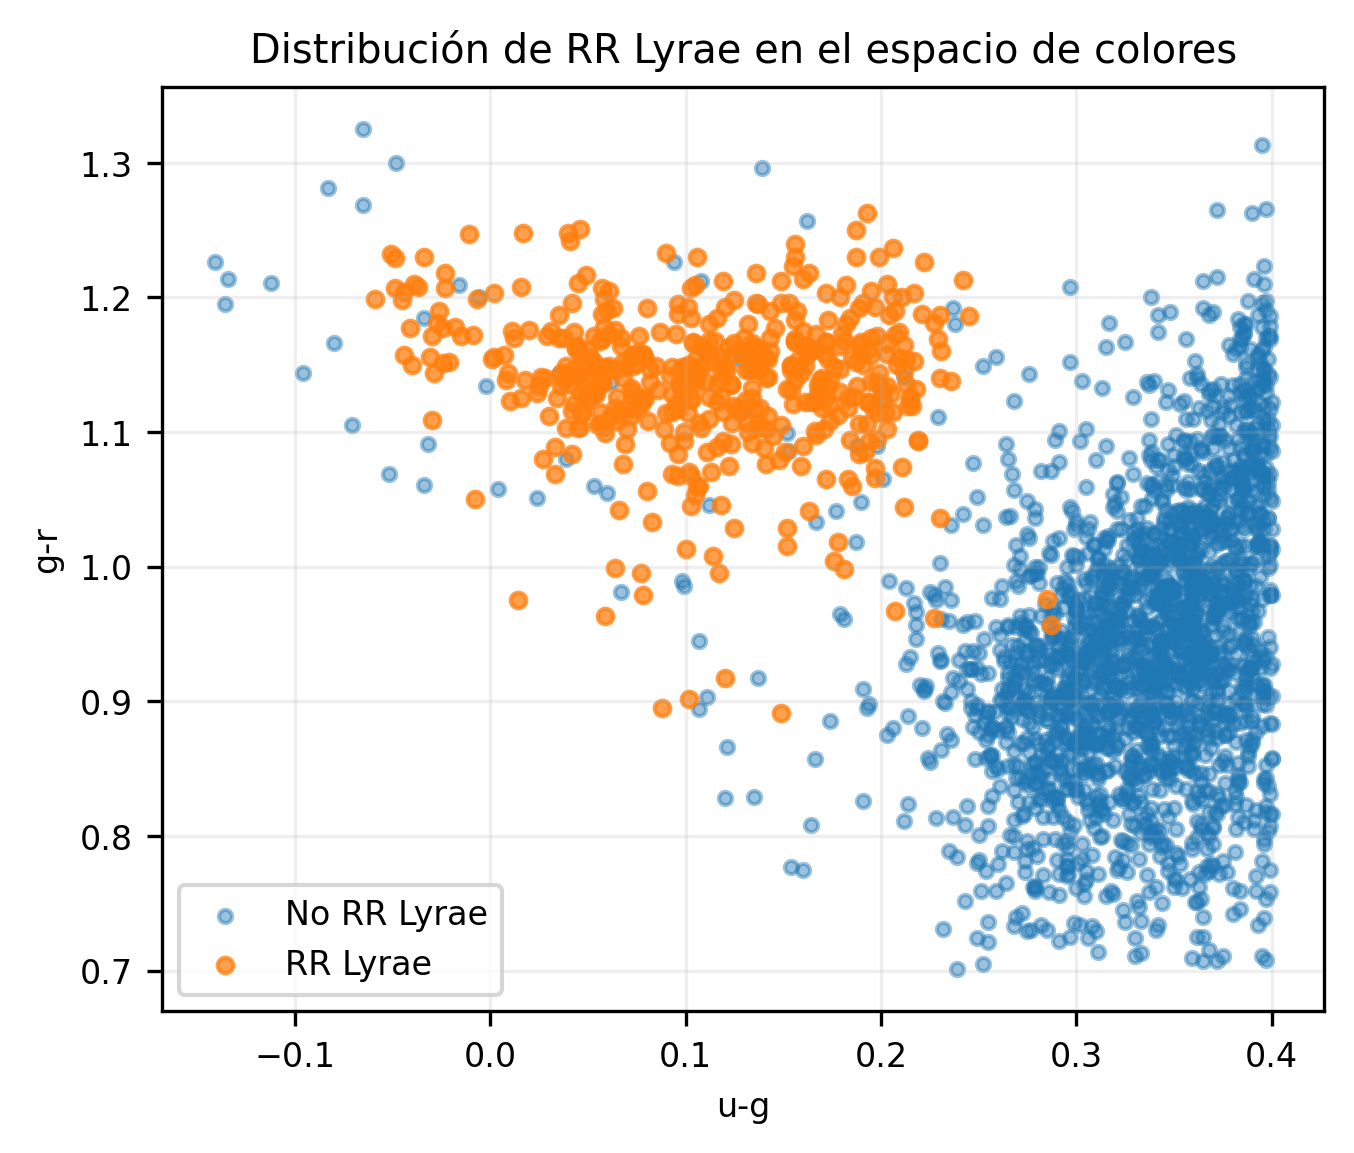

In [254]:
plt.figure(figsize=(5, 4))

mask_rr = df["RR_Lyrae"] == 1
plt.scatter(df.loc[~mask_rr, "u-g"], df.loc[~mask_rr, "g-r"],
            s=10, alpha=0.45, label="No RR Lyrae")
plt.scatter(df.loc[mask_rr, "u-g"], df.loc[mask_rr, "g-r"],
            s=14, alpha=0.75, label="RR Lyrae")

plt.xlabel("u-g")
plt.ylabel("g-r")
plt.title("Distribución de RR Lyrae en el espacio de colores")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


### Pregunta
1. ¿Se observan regiones donde las clases parecen separarse?
2. A simple vista, ¿esperarías que un árbol de decisión funcione razonablemente bien?

### Respuestas

1. Sí. En el plano u-g vs g-r se observa que las RR Lyrae se concentran principalmente en una región distinta a la mayor parte de las estrellas no RR Lyrae, aunque existe un poco de superposición entre las clases.
2. Sí, esperaría que un árbol de decisión funcione razonablemente bien. Un árbol construye cortes sucesivos sobre las variables, por lo que puede aprovechar regiones del espacio de colores donde una clase está más concentrada. Sin embargo, el solapamiento entre clases implica que no deberiamos esperar una separación perfecta sobre datos nuevos.


#### Separe los datos en entrenamiento y prueba

In [255]:
X = df[["u-g", "g-r", "r-i", "i-z"]]
y = df["RR_Lyrae"]

In [256]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)


In [257]:
X_train.shape

(1738, 4)

### Antes de continuar

Las clases en este problema no están perfectamente balanceadas.

Piense en la forma en que podríamos separar los datos en entrenamiento y prueba, y responda:

1. ¿Qué problema podría ocurrir si hacemos la partición de manera completamente aleatoria, sin preocuparnos por la proporción de clases?
2. ¿Por qué eso podría afectar la evaluación del modelo?
3. ¿Qué tipo de precaución cree que sería razonable tomar al construir los conjuntos de entrenamiento y prueba en este caso?

### Respuestas

1. Si hacemos una partición aleatoria, la proporción de RR Lyrae podría quedar bastante distinta entre entrenamiento y prueba, especialmente porque hay menos objetos de la clase positiva.

2. Eso haría que las métricas dependan mucho de esa partición. Por ejemplo, si en el conjunto de prueba quedan muy pocas RR Lyrae, el recall podría cambiar bastante y no representar bien el rendimiento del modelo.

3. Una forma de evitar esto es usar una partición estratificada, para mantener aproximadamente la misma proporción de clases en entrenamiento y prueba.

#### Ahora entrenaremos un árbol de decisión (modelo base)

In [258]:
model_tree = DecisionTreeClassifier(random_state=42)
model_tree.fit(X_train, y_train)

# Generamos predicciones para el conjunto de prueba
y_pred = model_tree.predict(X_test)


#### Visualicemos el árbol

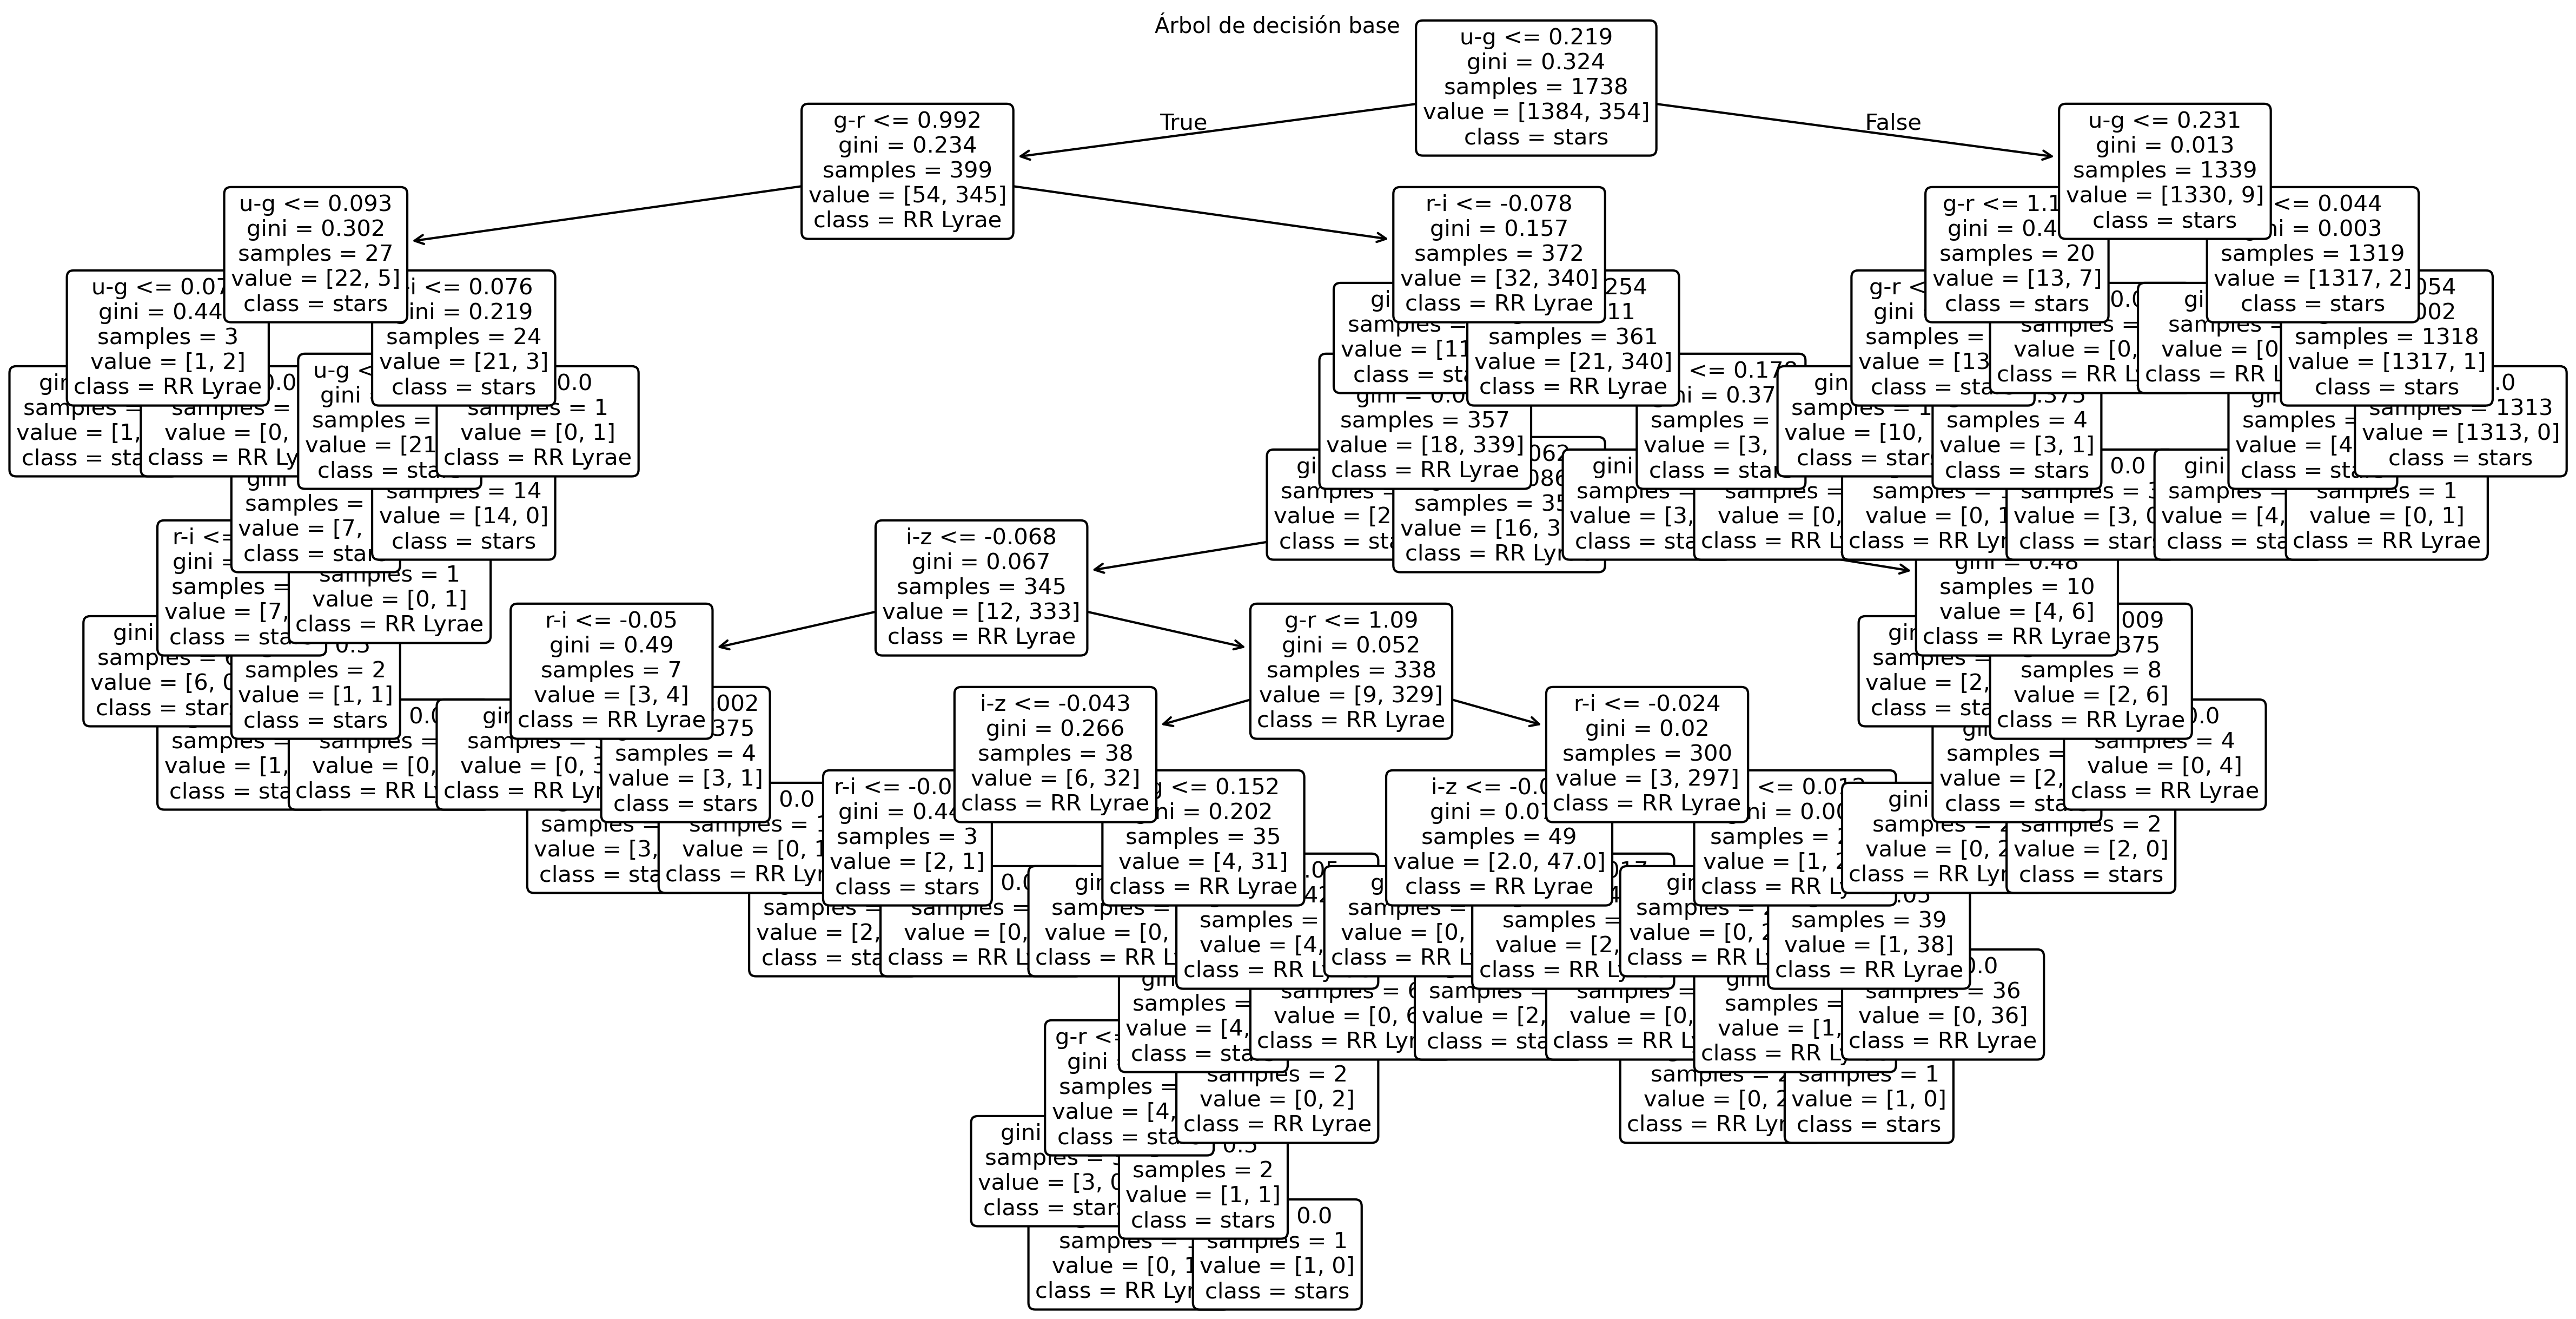

In [259]:
plt.figure(figsize=(20,10))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=False,
    rounded=True,
    #max_depth=3,
    fontsize=10
)

plt.title("Árbol de decisión base")
plt.show()

In [260]:
print("Profundidad máxima:", model_tree.get_depth())
print("Número de hojas:", model_tree.get_n_leaves())


Profundidad máxima: 14
Número de hojas: 42


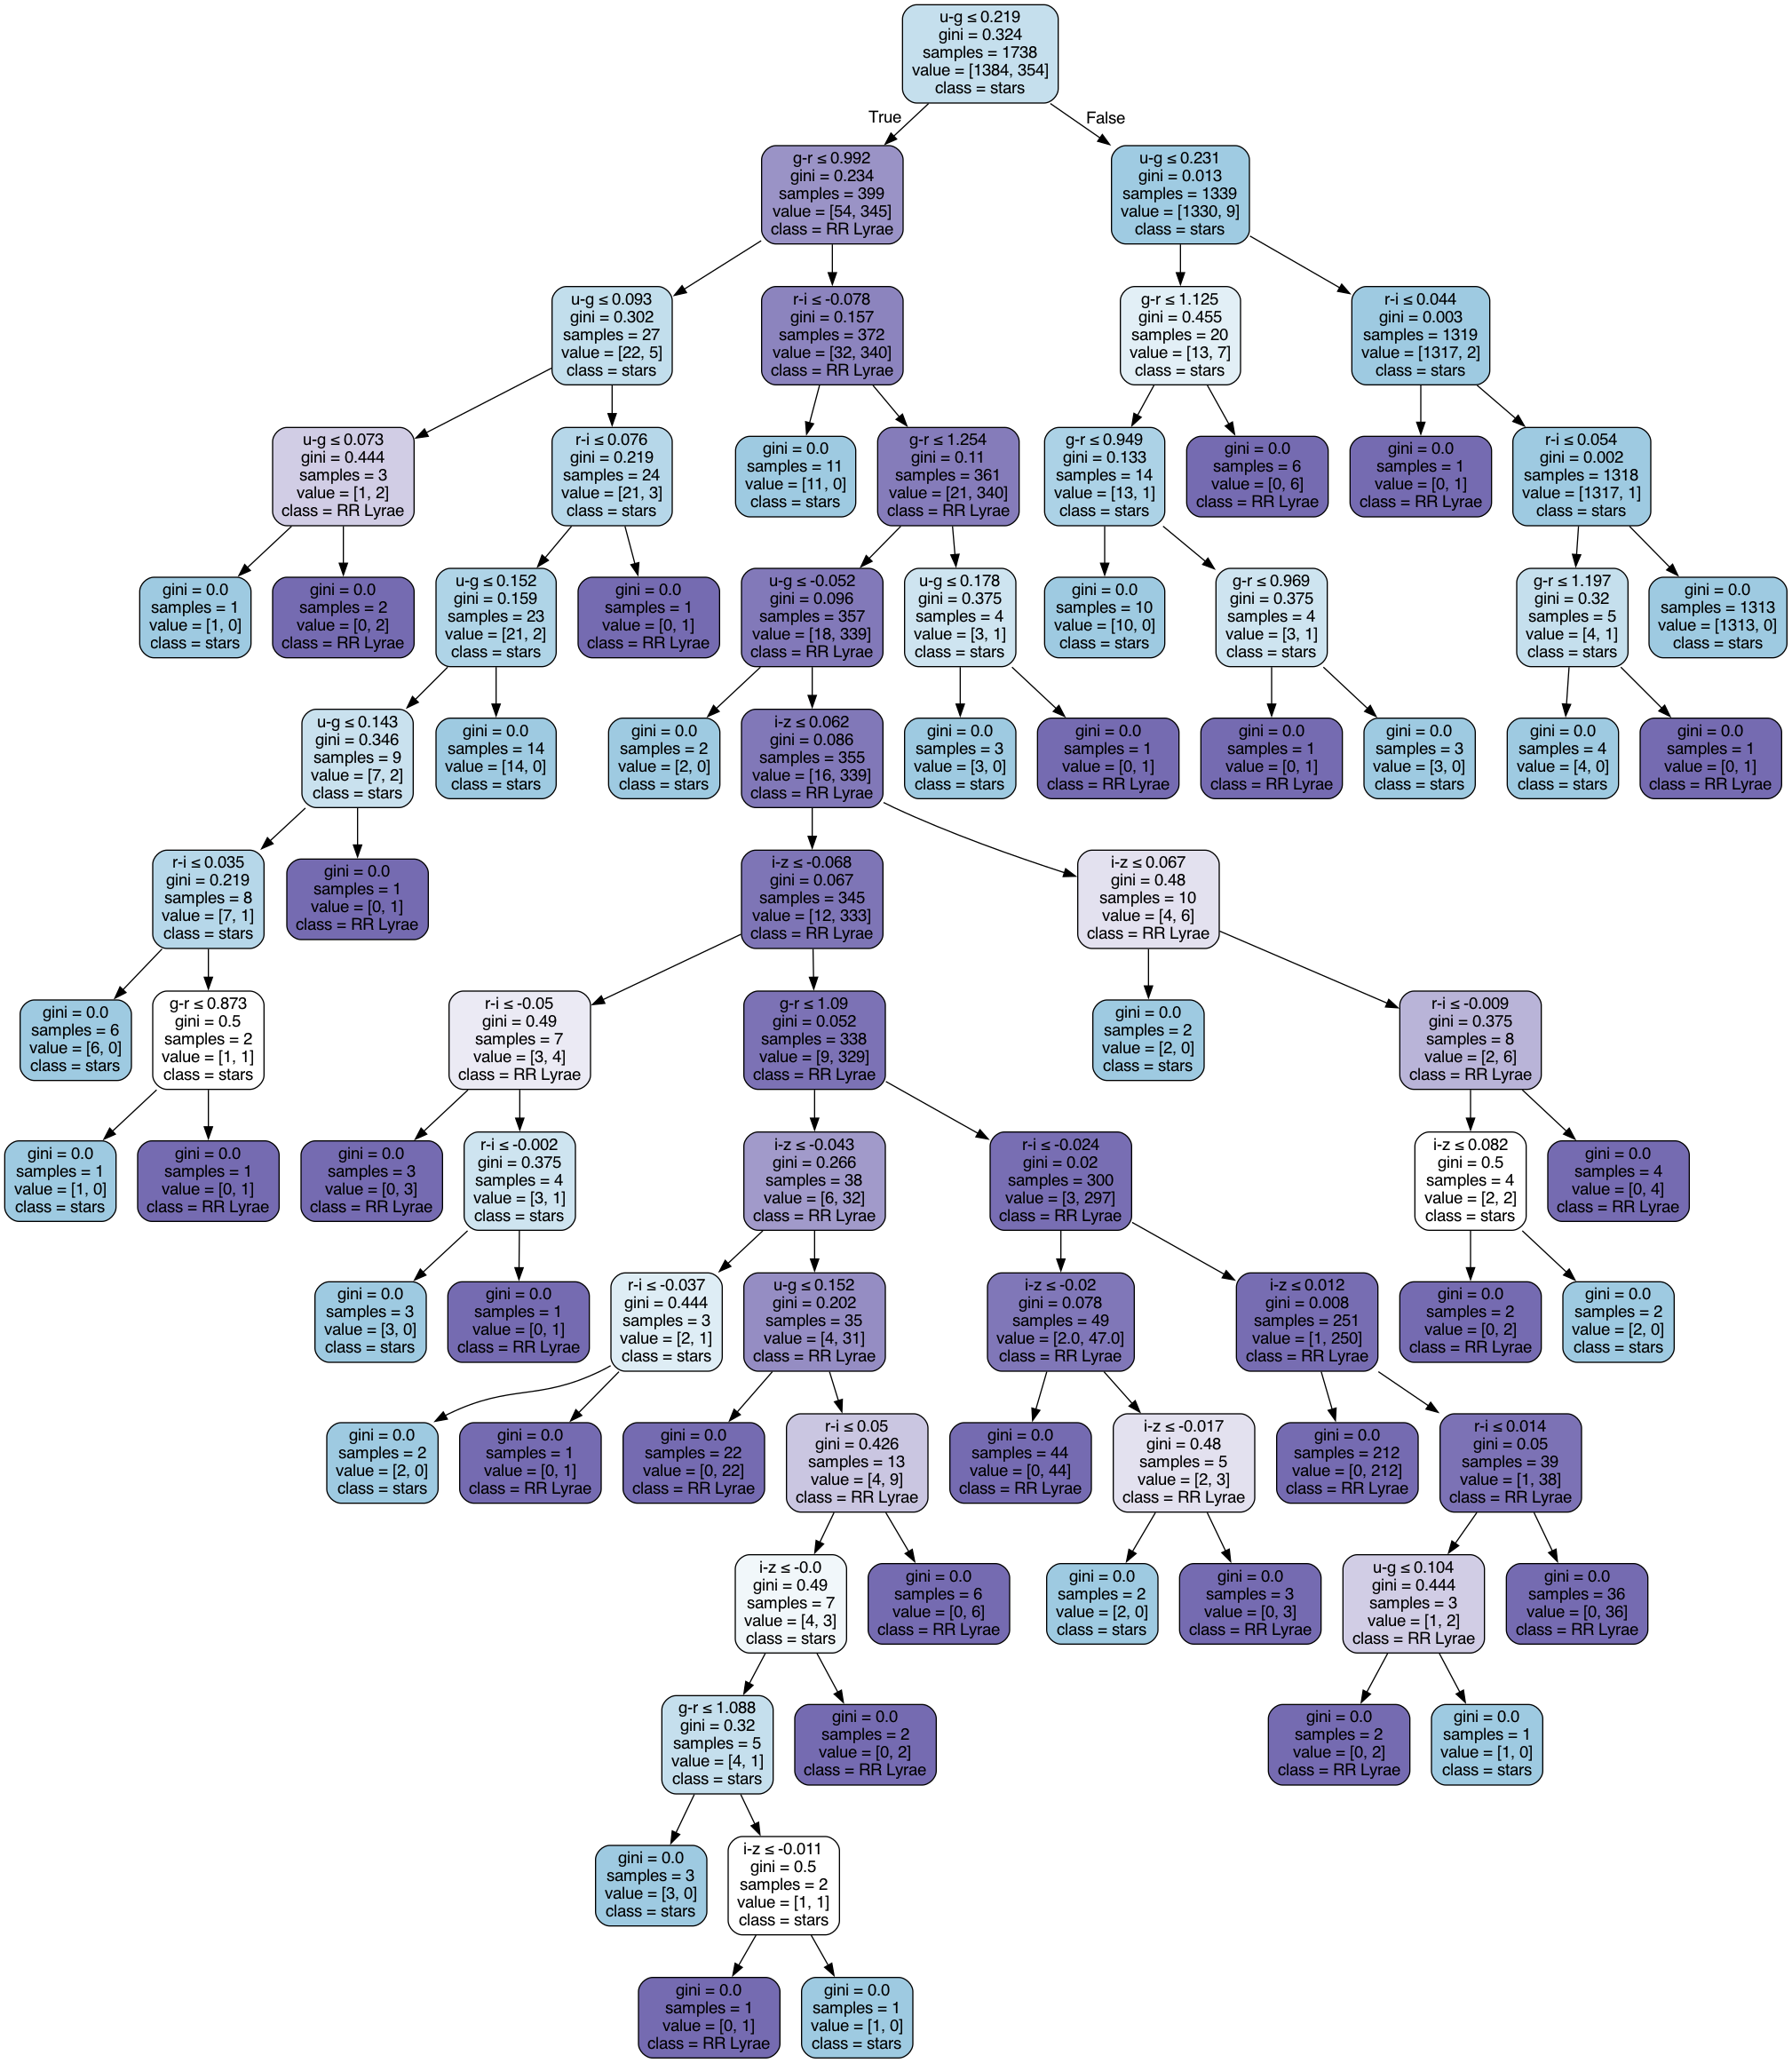

In [261]:
# Recordatorio: Las características siempre se permutan aleatoriamente en cada división.
# Por lo tanto, la mejor división encontrada puede variar, incluso con los mismos datos
# de entrenamiento y max_features=n_features, si la mejora del criterio es idéntica
# para varias divisiones enumeradas durante la búsqueda de la mejor división.
# Para obtener un comportamiento determinista durante el ajuste, random_state debe estar fijo.

dot_data = StringIO()

export_graphviz(
    model_tree,
    out_file=dot_data,
    feature_names=['u-g', 'g-r', 'r-i', 'i-z'],
    class_names=['stars', 'RR Lyrae'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label() and 'value = [' in node.get_label():

        values = [float(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha)
            color = '#9ecae1' + str(alpha)   # turquesa
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#756bb1' + str(alpha)   # magenta

        node.set_fillcolor(color)

Image(graph.create_png())

### Preguntas

Observe la estructura del árbol y responda brevemente:

1. ¿El árbol parece muy simple o bastante complejo? Justifique a partir del número de niveles o divisiones.
2. ¿Qué desventaja podría tener un árbol demasiado grande en un problema como este?

### Respuestas

1. El árbol es bastante complejo. El árbol base alcanza una profundidad de 14 niveles y tiene 42 hojas, por lo que realiza varias divisiones antes de llegar a las predicciones finales.

2. Un árbol demasiado grande puede **sobreajustar** los datos de entrenamiento: aprende detalles particulares o ruido de la muestra en vez de patrones más generales. Eso puede dar un muy buen rendimiento en entrenamiento, pero peor resultado con datos nuevos.

#### Miremos las métricas accuracy para set de entrenamiento y prueba

In [262]:
acc_train = metrics.accuracy_score(y_train, model_tree.predict(X_train))
acc_test = metrics.accuracy_score(y_test, model_tree.predict(X_test))

print(f"Accuracy entrenamiento: {acc_train:.4f}")
print(f"Accuracy prueba       : {acc_test:.4f}")


Accuracy entrenamiento: 1.0000
Accuracy prueba       : 0.9651


#### Otras métricas

In [263]:
precision_test = metrics.precision_score(y_test, y_pred)
recall_test = metrics.recall_score(y_test, y_pred)
f1_test = metrics.f1_score(y_test, y_pred)

print(f"Precision: {precision_test:.4f}")
print(f"Recall   : {recall_test:.4f}")
print(f"F1-score : {f1_test:.4f}")


Precision: 0.8759
Recall   : 0.9302
F1-score : 0.9023


In [264]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[599,  17],
       [  9, 120]])

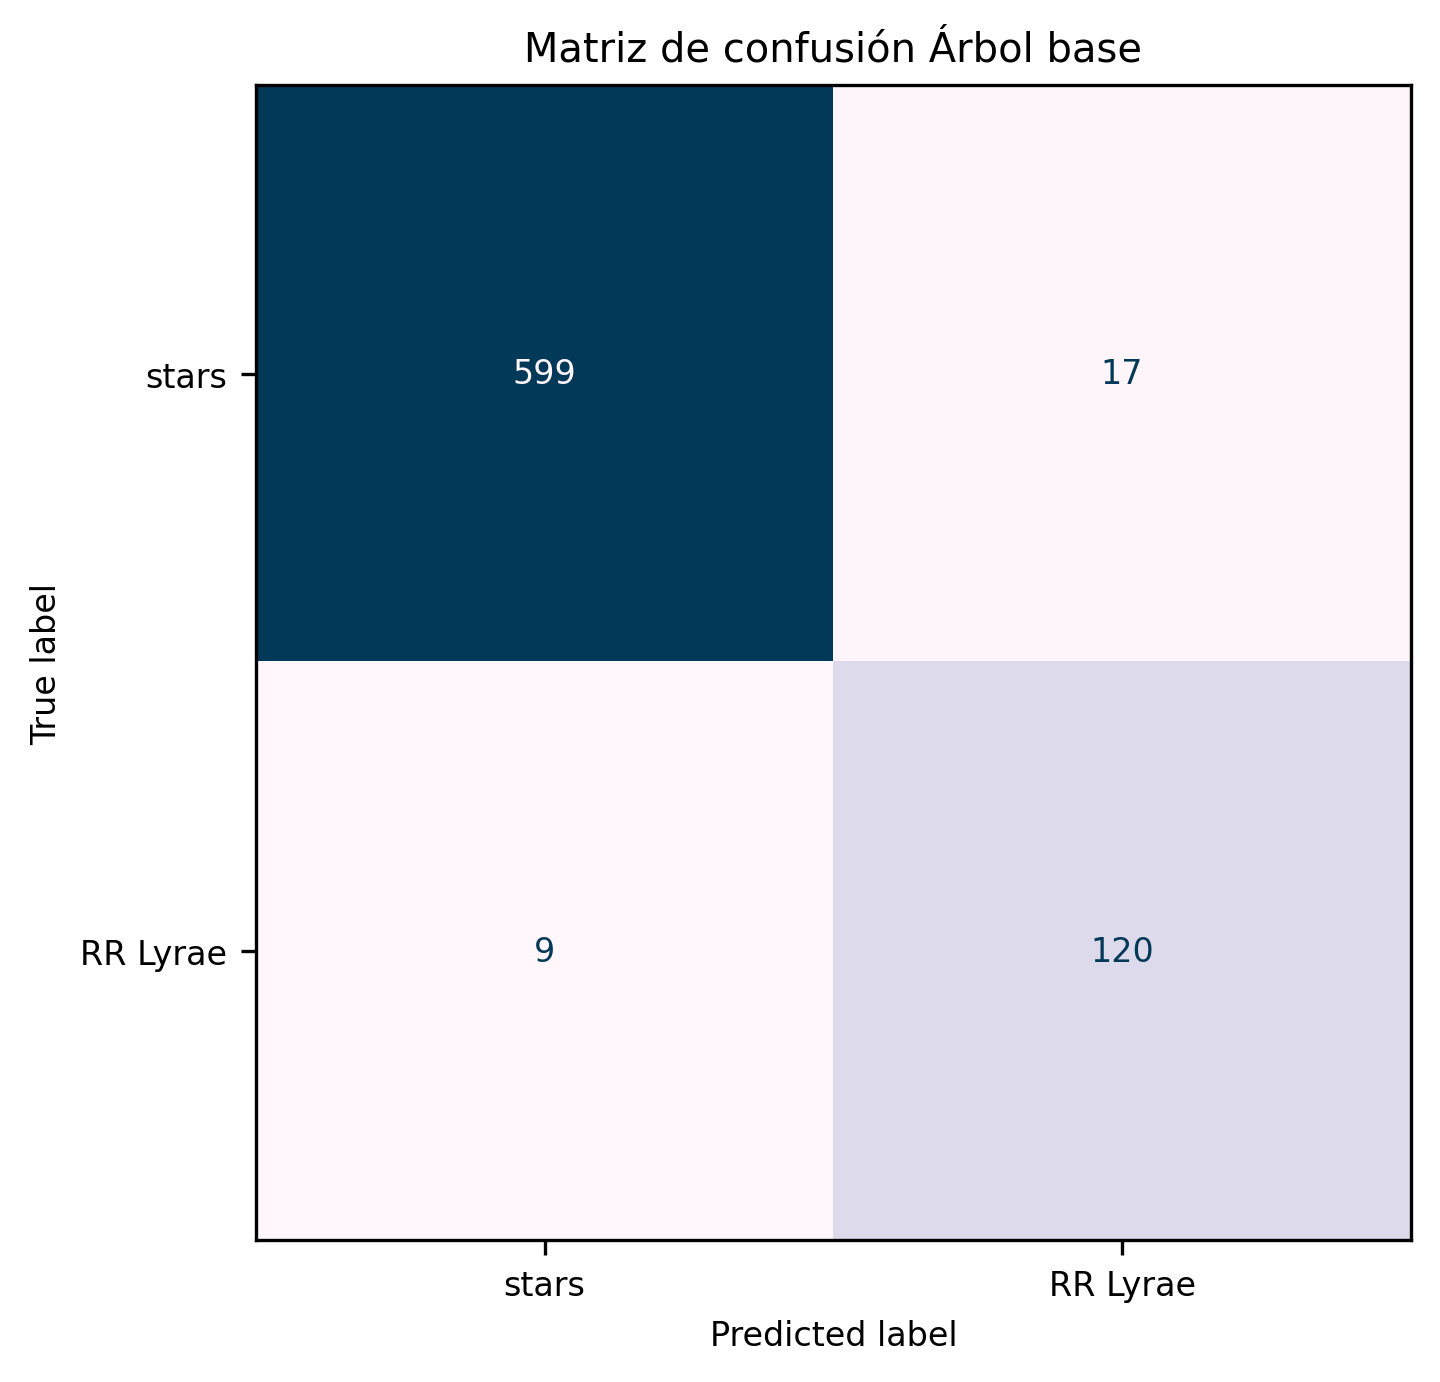

In [265]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["stars", "RR Lyrae"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de confusión Árbol base")
plt.show()

#### A partir de la matriz de confusión obtenida:
1.  Identifique los valores de:
   - verdaderos positivos (TP)
   - verdaderos negativos (TN)
   - falsos positivos (FP)
   - falsos negativos (FN)
2. Calcule las métricas "a mano"



In [266]:
tn, fp, fn, tp = cm.ravel()

print("TN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)


TN = 599
FP = 17
FN = 9
TP = 120


In [267]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall   
)

print(f"Accuracy  (manual): {accuracy:.4f}")
print(f"Precision (manual): {precision:.4f}")
print(f"Recall    (manual): {recall:.4f}")
print(f"F1-score  (manual): {f1 :.4f}")

# Verificación con sklearn
print("\nVerificación con sklearn:")
print(f"Accuracy : {metrics.accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {metrics.precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {metrics.recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {metrics.f1_score(y_test, y_pred):.4f}")


Accuracy  (manual): 0.9651
Precision (manual): 0.8759
Recall    (manual): 0.9302
F1-score  (manual): 0.9023

Verificación con sklearn:
Accuracy : 0.9651
Precision: 0.8759
Recall   : 0.9302
F1-score : 0.9023


### Preguntas
1. Explique con sus palabras qué significa, en este problema:
   - un falso positivo
   - un falso negativo

2. Si el objetivo científico fuera encontrar la mayor cantidad posible de RR Lyrae, ¿qué tipo de error preocuparía más?

3. Si el objetivo fuera construir una muestra final más limpia, ¿qué tipo de error preocuparía más?

### Respuestas

1. En este problema:

   - Un **falso positivo (FP)** es una estrella que no es RR Lyrae, pero que el modelo clasifica como RR Lyrae.
   - Un **falso negativo (FN)** es una estrella que sí es RR Lyrae, pero que el modelo clasifica como no RR Lyrae.

2. Si queremos encontrar la mayor cantidad posible de RR Lyrae, preocupan más los **falsos negativos**, porque son estrellas RR Lyrae reales que el modelo no detecta. En ese caso conviene priorizar un **recall alto**.

3. Si queremos una muestra final más limpia, preocupan más los **falsos positivos**, porque agregan objetos que no son RR Lyrae. En ese caso conviene priorizar una **precision alta**.

#### Todo parece funcionar bien, pero sólo hicimos un split. Necesitamos que el resultados sea robusto. Para esto, implementaremos Cross-validation usando [k-fold](https://scikit--learn-org.translate.goog/stable/modules/generated/sklearn.model_selection.KFold.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc)

In [268]:
# Esta es la versión estándar. Importante: no baraja los datos, por lo que si tus
# ejemplos positivos están todos al principio o al final, podría llevar a resultados
# desastrosos.

cv1 = KFold(n_splits = 5)

#Esta es la versión 2: se ha añadido el barajado (¡recomendado!)

cv2 = KFold(shuffle = True, n_splits = 5, random_state=5)

# LA ESTRATIFICACIÓN asegura que las distribuciones de clases en cada división se
# asemejen a las del conjunto de datos completo.

cv3 = StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)


### Efecto de la estratificación: veamos el conteo de clases en cada conjunto de divisiones.

In [269]:
cv1.split(X, y)

<generator object _BaseKFold.split at 0x15811bbc0>

In [270]:
for train, test in cv1.split(X, y):
    print("train - {} | test - {}".format(
        np.bincount(y.iloc[train]), np.bincount(y.iloc[test])
    ))


train - [1503  483] | test - [497]
train - [1503  483] | test - [497]
train - [1503  483] | test - [497]
train - [1504  483] | test - [496]
train - [1987] | test - [ 13 483]


In [271]:
for train, test in cv2.split(X, y):
    print("train - {} | test - {}".format(
        np.bincount(y.iloc[train]), np.bincount(y.iloc[test])
    ))


train - [1600  386] | test - [400  97]
train - [1610  376] | test - [390 107]
train - [1587  399] | test - [413  84]
train - [1599  388] | test - [401  95]
train - [1604  383] | test - [396 100]


In [272]:
for train, test in cv3.split(X, y):
    print("train - {} | test - {}".format(
        np.bincount(y.iloc[train]), np.bincount(y.iloc[test])
    ))


train - [1600  386] | test - [400  97]
train - [1600  386] | test - [400  97]
train - [1600  386] | test - [400  97]
train - [1600  387] | test - [400  96]
train - [1600  387] | test - [400  96]


### La función [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) proporciona los puntajes (especificados por el parámetro de evaluación elegido), en forma de diccionario.

In [273]:
scores1 = cross_validate(
    DecisionTreeClassifier(random_state=1), X, y, cv=cv1, scoring="accuracy"
)
scores2 = cross_validate(
    DecisionTreeClassifier(random_state=1), X, y, cv=cv2, scoring="accuracy"
)
scores3 = cross_validate(
    DecisionTreeClassifier(random_state=1), X, y, cv=cv3, scoring="accuracy"
)


In [274]:
scores3

{'fit_time': array([0.00203896, 0.00166917, 0.00219393, 0.002141  , 0.0018661 ]),
 'score_time': array([0.000319  , 0.00034189, 0.0003562 , 0.00031734, 0.00034809]),
 'test_score': array([0.9778672 , 0.96780684, 0.96579477, 0.97379032, 0.96169355])}

Solo nos interesa el 'test_score'

#### Calculamos el promedio y $\sigma$

In [275]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))

0.785 0.379


In [276]:
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))

0.965 0.010


In [277]:
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

0.969 0.006


### Interpretación

La validación cruzada sin barajar (`cv1`) produce un resultado muy inestable: los datos están ordenados por clase y algunos folds no representan la distribución global. Por eso su accuracy promedio es mucho menor y su dispersión es enorme.

Al activar el barajado (`cv2`), los folds contienen ambas clases y la evaluación se vuelve mucho más estable. Sin embargo, para este problema la opción más apropiada es **`StratifiedKFold` (`cv3`)**, porque además de barajar conserva aproximadamente la proporción 80/20 entre no RR Lyrae y RR Lyrae en cada fold. Esto es especialmente importante porque la clase positiva es minoritaria.


In [300]:
scores1 = cross_validate(DecisionTreeClassifier(random_state=1), X, y, cv=cv1, scoring='recall')
scores2 = cross_validate(DecisionTreeClassifier(random_state=1), X, y, cv=cv2, scoring='recall')
scores3 = cross_validate(DecisionTreeClassifier(random_state=1), X, y, cv=cv3, scoring='recall')

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classificati

In [301]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

nan nan
0.903 0.016
0.925 0.019


### ¿Por qué aparece este warning?

En algunos folds generados por `KFold` sin barajado, el conjunto de prueba contiene solo ejemplos de una clase. En ese caso, el recall de la clase positiva (RR Lyrae) no puede calcularse, porque no hay positivos reales en ese fold.

Esto muestra que una estrategia de partición inadecuada puede hacer que la evaluación sea inestable, engañosa o incluso inválida.

#### También extraeremos los train scores, que nos servirán cuando estemos diagnosticando el modelo a través de bias vs variance.¶

In [302]:
scores1 = cross_validate(DecisionTreeClassifier(random_state=1), X, y, cv=cv1, scoring=recall_safe, return_train_score=True)
scores2 = cross_validate(DecisionTreeClassifier(random_state=1), X, y, cv=cv2, scoring=recall_safe, return_train_score=True)
scores3 = cross_validate(DecisionTreeClassifier(random_state=1), X, y, cv=cv3, scoring=recall_safe, return_train_score=True)

In [303]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['train_score'].mean()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['train_score'].mean()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['train_score'].mean()))

0.000 0.800
0.903 1.000
0.925 1.000


### Interpretación train vs. validación

Con `cv2` y `cv3`, el recall de entrenamiento es prácticamente 1.0 mientras el recall de validación es menor. Esta brecha indica que el árbol sin restricciones ajusta muy bien los datos usados para entrenar, pero pierde rendimiento sobre observaciones no vistas, es una primera señal de **alta varianza o sobreajuste**.


### La función  `cross_validate` es útil para calcular el puntaje, pero no produce etiquetas predichas.

#### Estas pueden obtenerse utilizando la función [`cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html), que guarda las predicciones para cada uno de los k-folds de prueba y las compila juntas.


In [282]:
model1 = DecisionTreeClassifier(random_state = 3)

y_cv3 = cross_val_predict(model1, X,y, cv = cv3)
# Estas son las predicciones,
# y son independientes del parámetro de evaluación

In [283]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

Con `StratifiedKFold`, cada objeto recibe una predicción generada por un modelo que **no fue entrenado con ese objeto**. Por eso la matriz de confusión obtenida con `cross_val_predict` es una estimación más fuerte del comportamiento fuera de muestra que mirar solamente las predicciones de entrenamiento.


### Sin embargo, las cosas pueden cambiar si uso un esquema de validación cruzada diferente:

In [284]:
model2 = DecisionTreeClassifier(random_state = 3)

y_cv2 = cross_val_predict(model2, X,y, cv = cv2)

In [285]:
np.sum(y_cv3-y_cv2)

np.int64(10)

In [286]:
np.sum(y_cv2)

np.int64(485)

In [287]:
np.sum(y_cv3 != y_cv2) #comparando las predicciones

np.int64(52)

In [288]:
metrics.confusion_matrix(targets,y_cv2)

array([[1955,   45],
       [  43,  440]])

In [289]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

In [290]:
print("Predicciones distintas entre cv2 y cv3:", np.sum(y_cv3 != y_cv2))
print("RR Lyrae predichas con cv2:", np.sum(y_cv2))
print("RR Lyrae predichas con cv3:", np.sum(y_cv3))


Predicciones distintas entre cv2 y cv3: 52
RR Lyrae predichas con cv2: 485
RR Lyrae predichas con cv3: 495


Aunque `cv2` y `cv3` usan los mismos datos y ambos barajan, no generan exactamente las mismas divisiones y por lo tanto algunas predicciones cambian. La estratificación hace que cada fold mantenga una proporción de clases parecida a la muestra completa, por lo que `cv3` es el esquema que se utilizará después.


In [291]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5), scoring = 'accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(str(scoring))

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring, shuffle=True, random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from cross-validation")

    plt.legend(loc="best")
    return plt

In [292]:
model = DecisionTreeClassifier(random_state = 5)

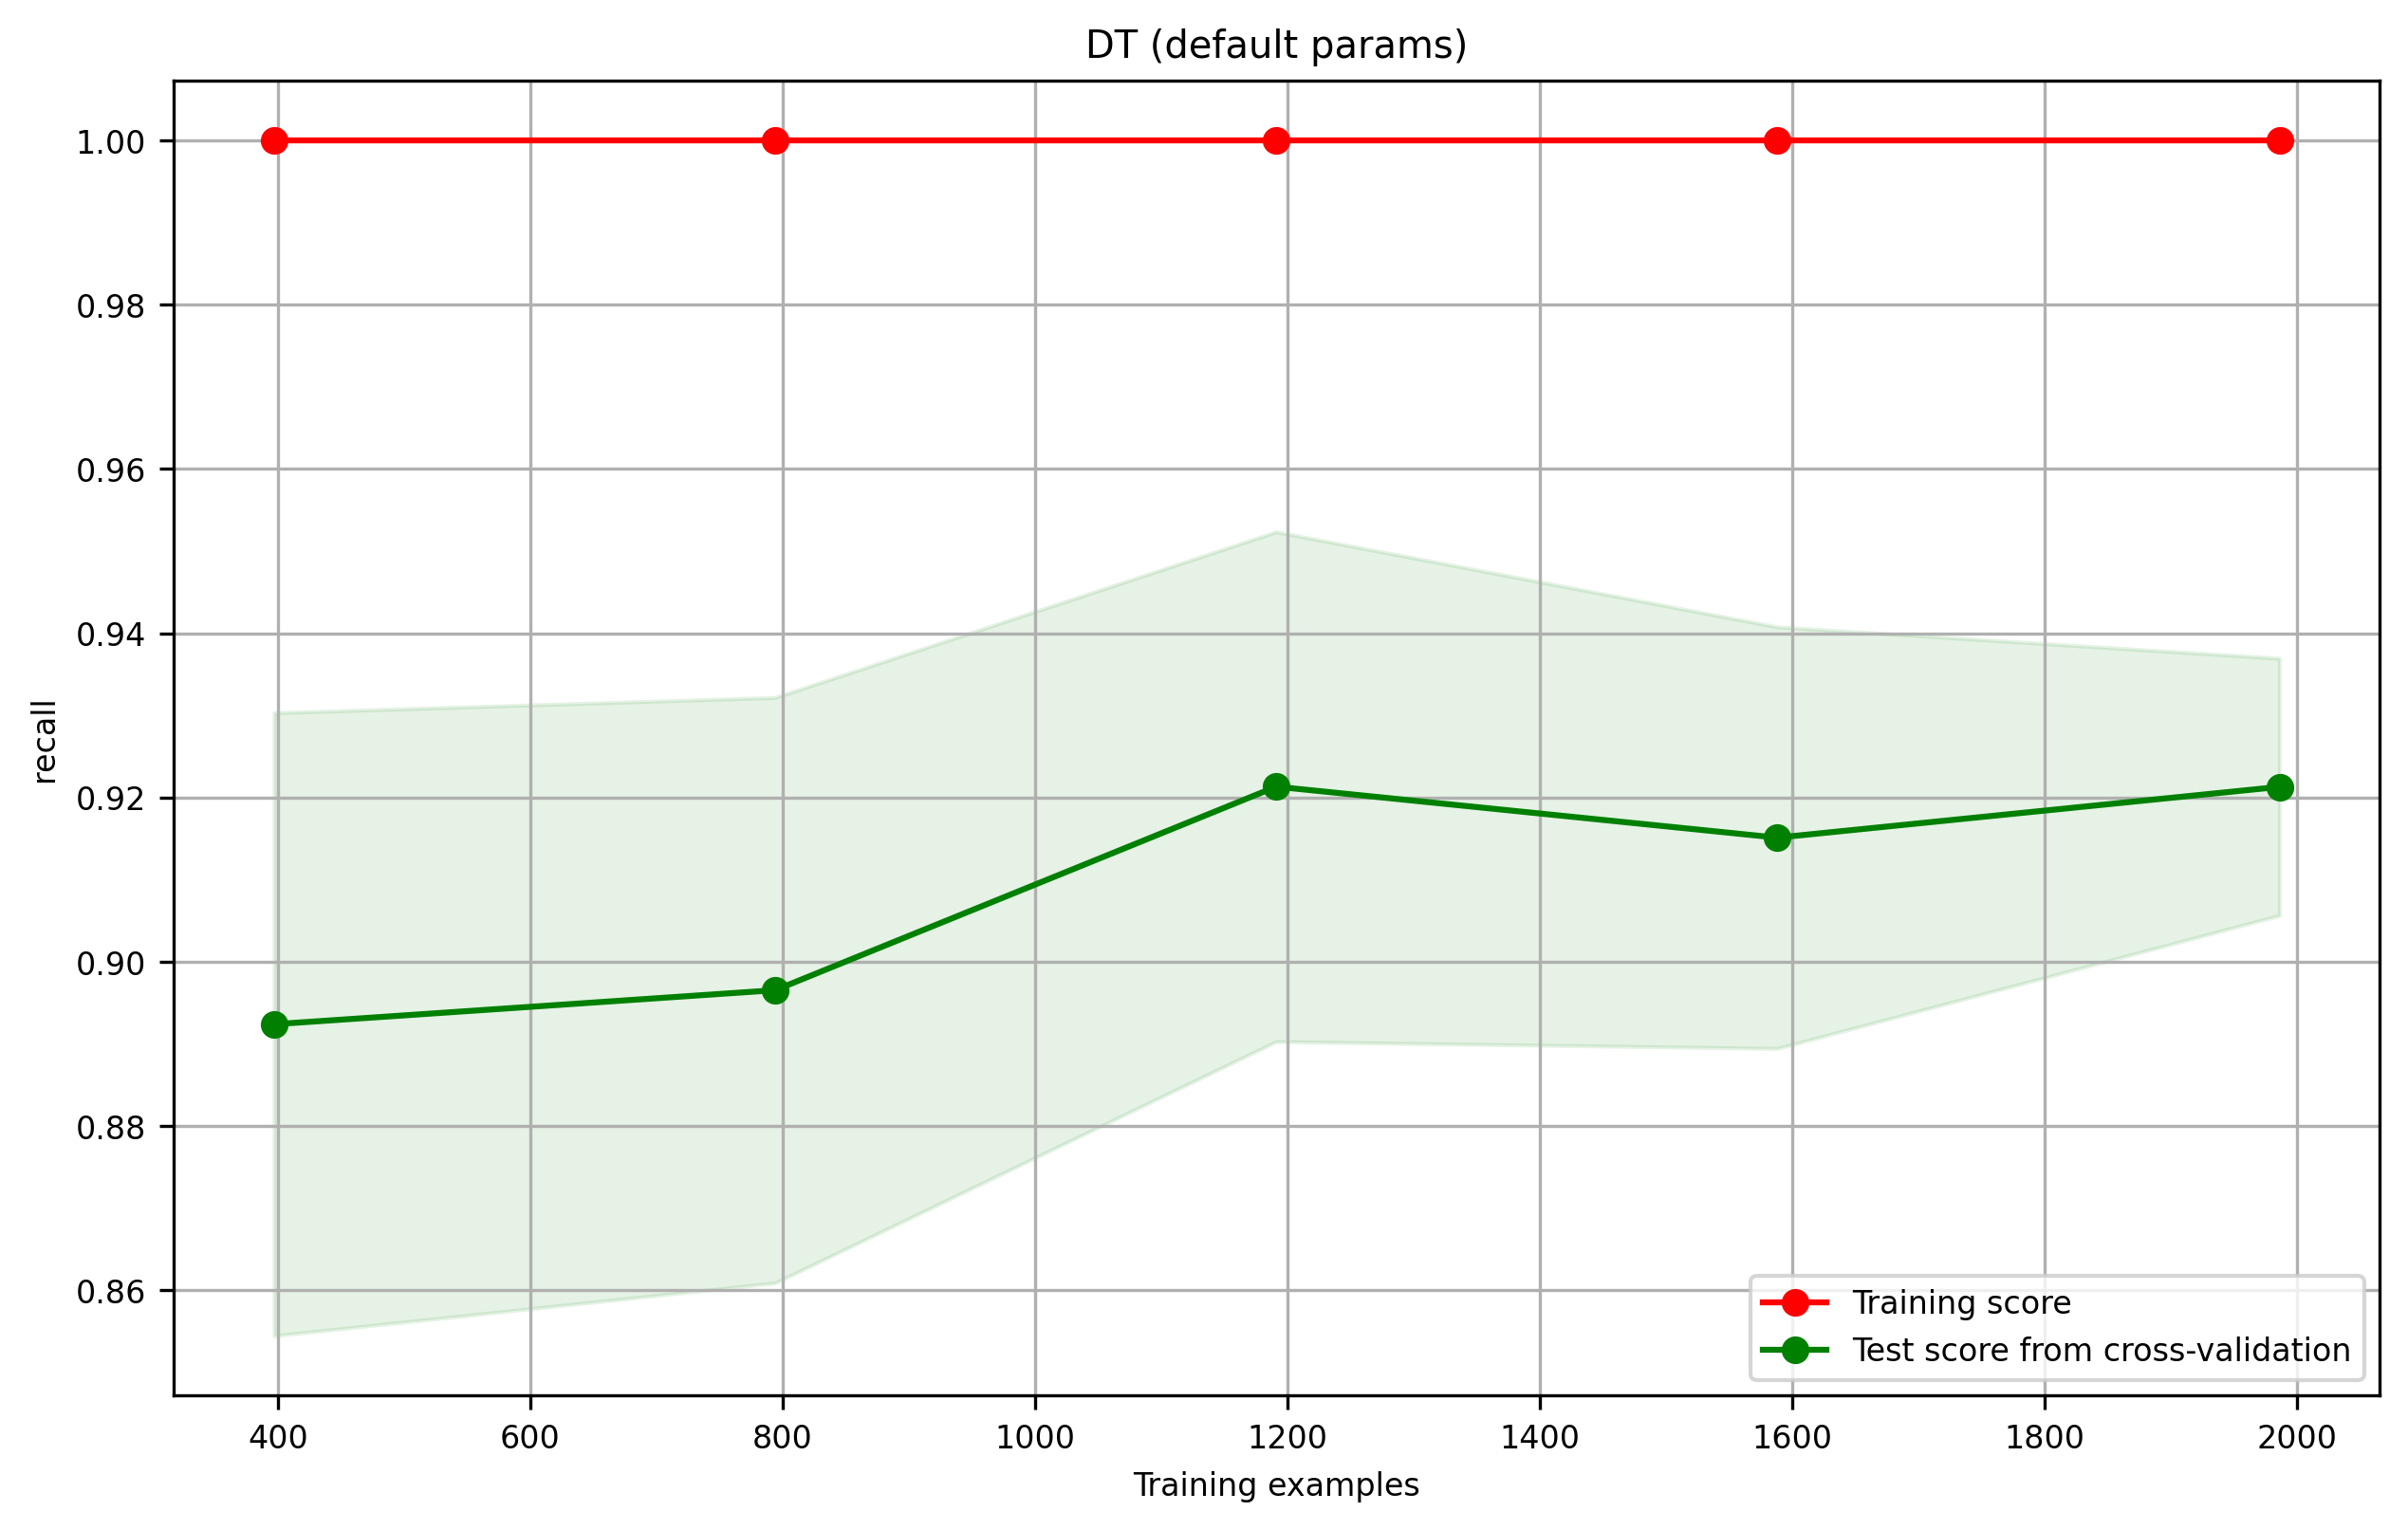

In [293]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'recall');

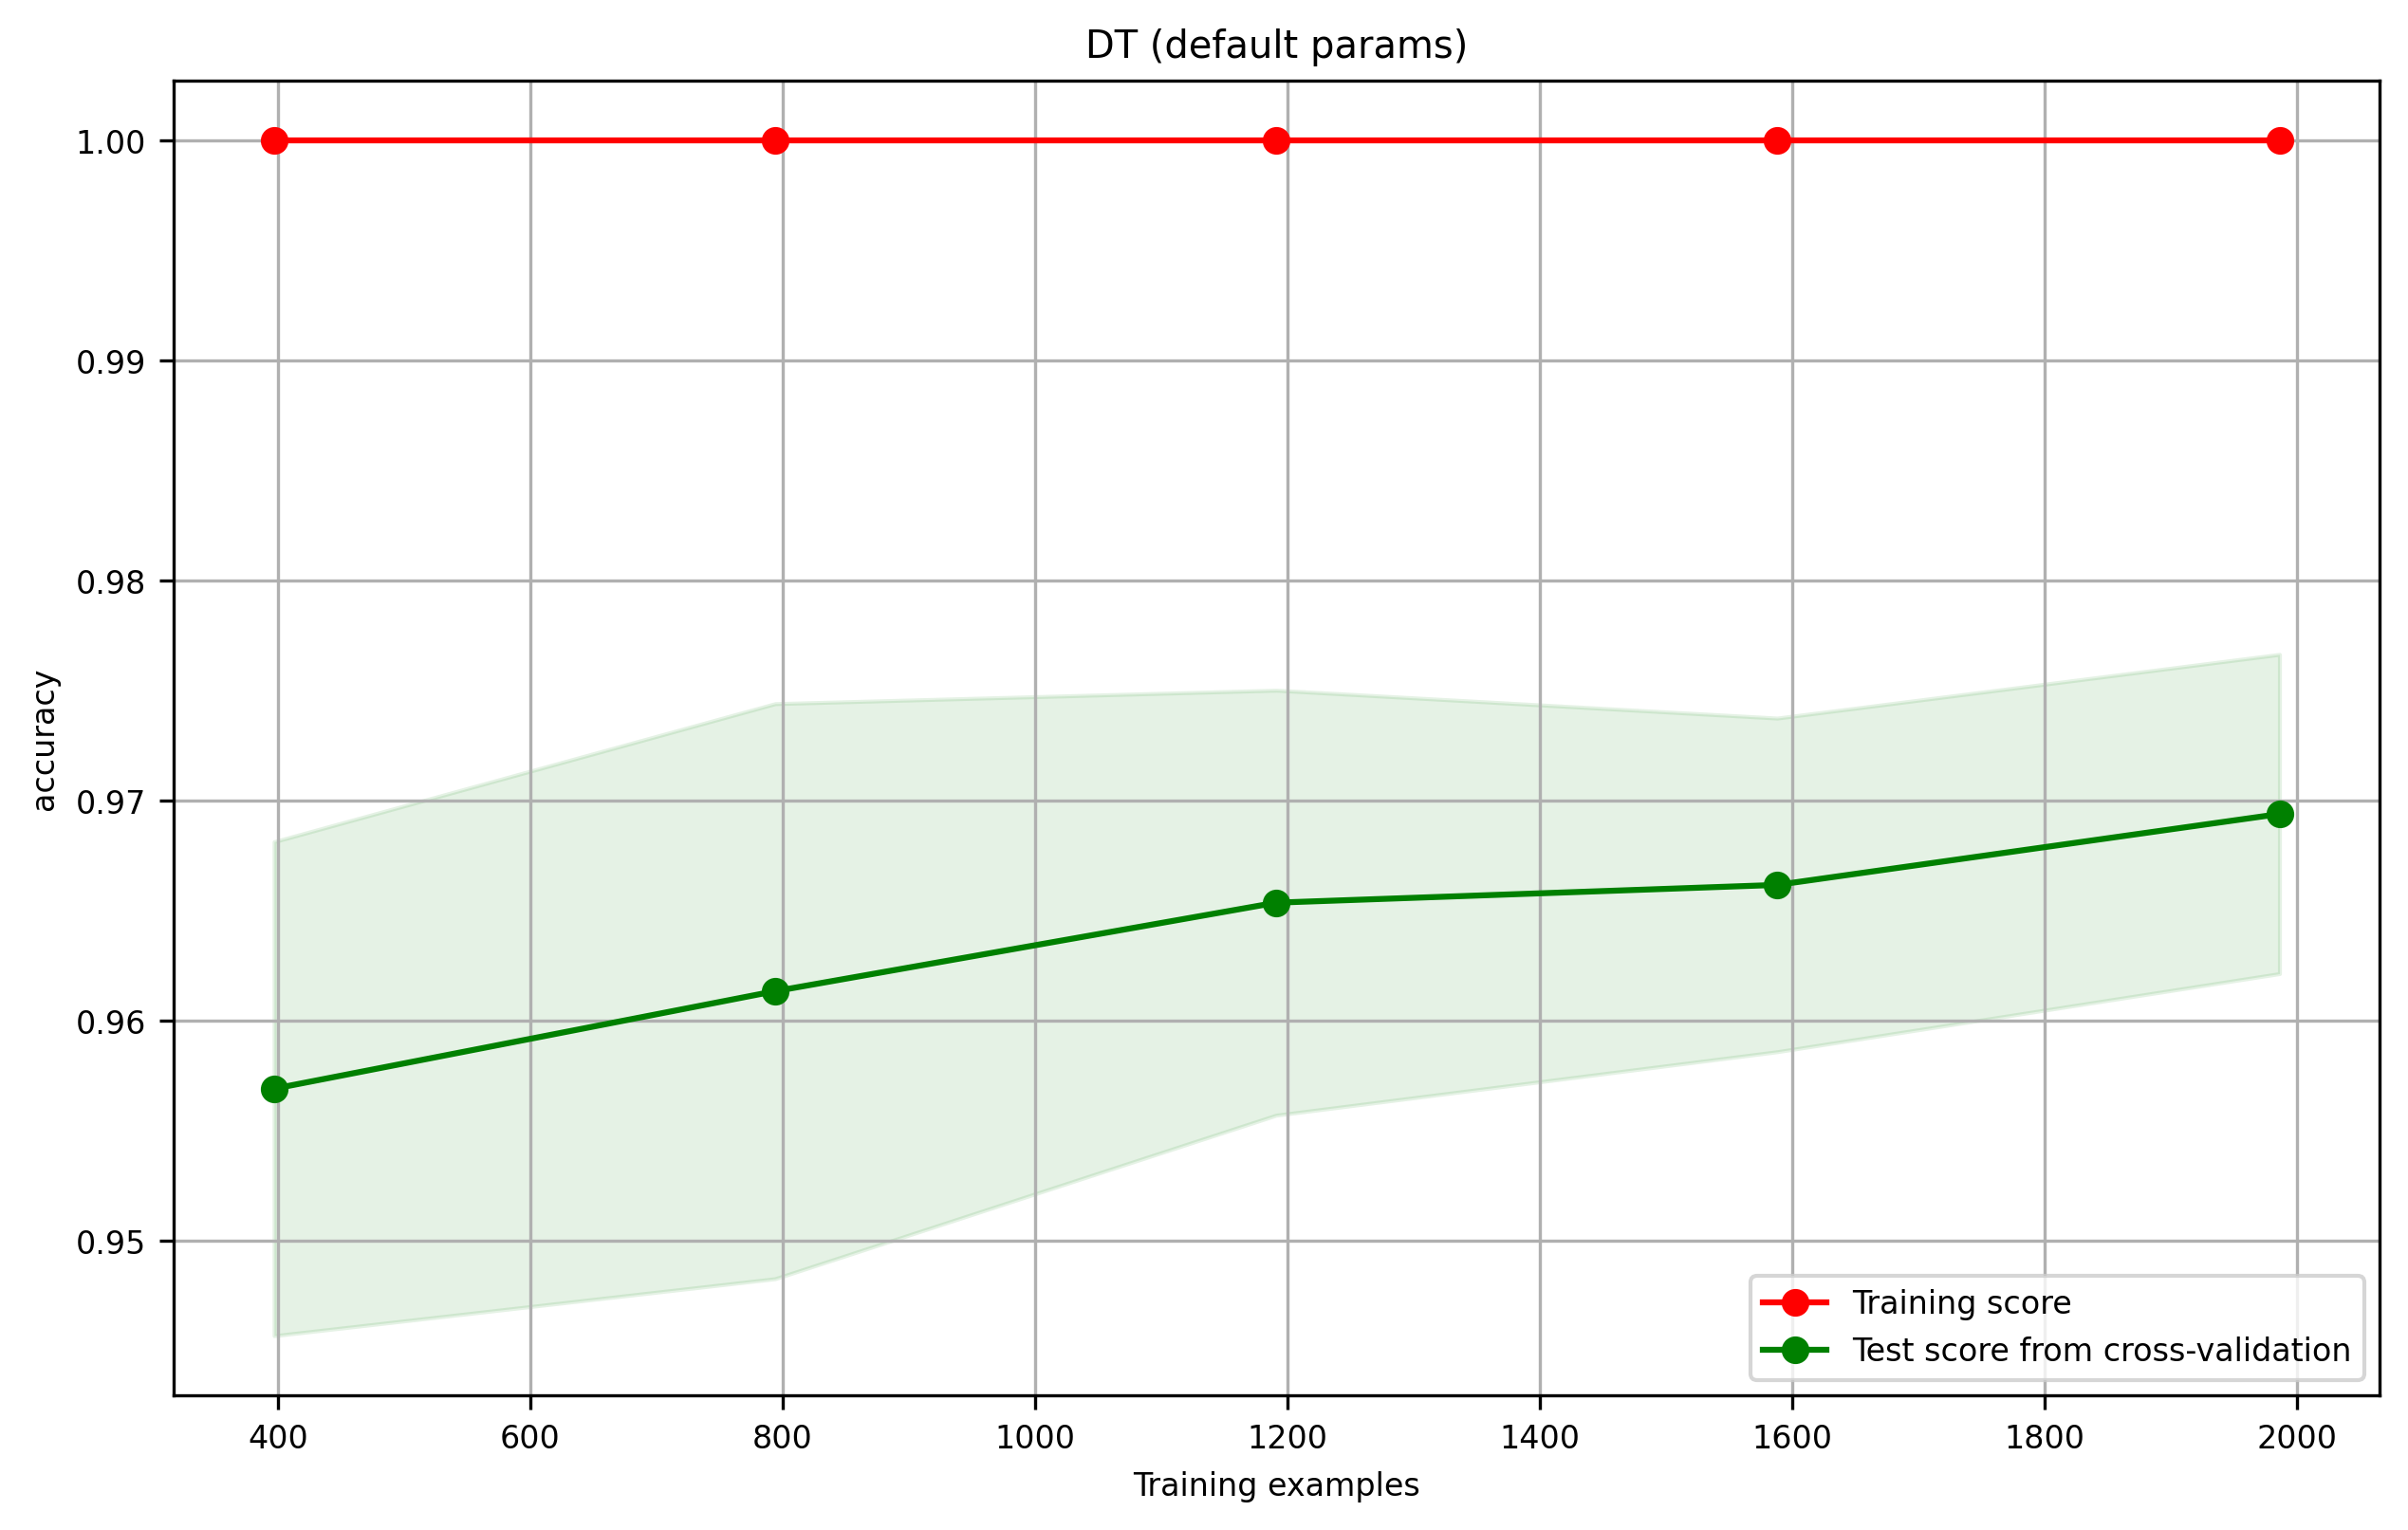

In [294]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'accuracy');

### **Preguntas**

Responda brevemente:

1. ¿Existe una brecha entre la curva de entrenamiento y la de validación? ¿Qué sugiere eso?
2. ¿El rendimiento de validación mejora al agregar más ejemplos?
3. ¿Hablaría aquí de alto sesgo, alta varianza o sobreajuste moderado? Justifique.
4. Escriba una conclusión general sobre el comportamiento del árbol base a partir de estas curvas.

### Respuestas

1. Sí existe una brecha. El árbol alcanza un score de entrenamiento prácticamente igual a 1.0 para todos los tamaños, mientras el rendimiento de validación es menor. Esto dice que el modelo ajusta mejor los datos que ya vio que los datos nuevos.
2. Sí, el rendimiento de validación mejora al agregar ejemplos, especialmente en accuracy, recall también tiende a mejorar, aunque con pequeñas diferencias entre tamaños.
3. Hablaría principalmente de alta varianza, asociada al sobreajuste. El modelo obtiene un rendimiento casi perfecto en entrenamiento, pero este baja en validación, lo que sugiere que se está ajustando demasiado a los datos con los que fue entrenado y no generaliza igual de bien a datos nuevos. No parece haber un problema de alto sesgo, ya que el árbol logra aprender muy bien el conjunto de entrenamiento.
4. En general, el árbol base funciona bien en validación, pero parece ajustarse demasiado a los datos de entrenamiento. Las curvas muestran que reducir un poco su complejidad podría ayudar a que mantenga un buen rendimiento y generalice mejor a datos nuevos.


### Desafío: ¿un árbol más simple generaliza mejor?

Entrene ahora un segundo árbol, más restringido que el árbol base. Por ejemplo, puede probar con:

- `max_depth=3`, o
- `min_samples_leaf=10`

Luego compare su rendimiento con el árbol base usando:

- accuracy
- precision
- recall
- F1-score



### Preguntas

A partir de los resultados obtenidos con validación cruzada:

1. ¿Qué ocurrió con el rendimiento al restringir la complejidad del árbol?
2. ¿El árbol más simple empeoró o mejoró la generalización?
3. ¿Qué sugieren estos resultados sobre el árbol base?
4. En este problema, ¿parece conveniente usar el árbol sin restricciones?
5. ¿Qué métrica le parece más importante para decidir entre ambos modelos?

In [295]:
scoring = ["accuracy", "precision", "recall", "f1"]

model_base_cv = DecisionTreeClassifier(random_state=5)
model_simple = DecisionTreeClassifier(max_depth=3, random_state=5)

scores_base = cross_validate(
    model_base_cv, X, y, cv=cv3, scoring=scoring, return_train_score=True
)
scores_simple = cross_validate(
    model_simple, X, y, cv=cv3, scoring=scoring, return_train_score=True
)


In [296]:
comparacion_arboles = pd.DataFrame({
    "Métrica": scoring,
    "Árbol base": [scores_base[f"test_{m}"].mean() for m in scoring],
    "Árbol simple (max_depth=3)": [scores_simple[f"test_{m}"].mean() for m in scoring]
})

display(comparacion_arboles.round(4))

print("Accuracy entrenamiento promedio:")
print(f"Árbol base   : {scores_base['train_accuracy'].mean():.4f}")
print(f"Árbol simple : {scores_simple['train_accuracy'].mean():.4f}")


,Métrica,Árbol base,Árbol simple (max_depth=3)
0,accuracy,0.9694,0.9770
1,precision,0.9220,0.9247
2,recall,0.9213,0.9606
3,f1,0.9215,0.9421


Accuracy entrenamiento promedio:
Árbol base   : 1.0000
Árbol simple : 0.9815


### Respuestas

1. Al limitar el árbol a `max_depth=3`, los resultados en validación mejoran en general. La accuracy, el recall y el F1-score suben, mientras que la precision se mantiene prácticamente igual.

2. En este caso, el árbol más simple termina funcionando mejor. Aunque tiene menos capacidad para ajustarse a cada detalle del conjunto de entrenamiento, logra mejores resultados cuando se evalúa con datos que no vio directamente.

3. Esto muestra que el árbol base estaba sobreajustando. En entrenamiento obtiene resultados prácticamente perfectos, pero hacer el árbol más complejo no termina ayudando en validación.

4. Por eso, para este problema no parece necesario usar un árbol sin restricciones. El árbol más simple logra resultados iguales o mejores y, además, es mucho más fácil de interpretar.


## Desafío: comparar con kNN

Hasta ahora trabajamos con árboles de decisión. Ahora comparemos ese enfoque con un clasificador distinto: **k-Nearest Neighbors (kNN)**.

Entrene un modelo kNN y compárelo con el árbol simple usando validación cruzada estratificada. Recuerde que kNN está basado en distancias, por lo que antes de entrenarlo debe escalar las variables.

### Instrucciones

1. Entrene un modelo kNN con `k=5`.
2. Use un `StandardScaler` antes del clasificador.
3. Evalúe el modelo con validación cruzada estratificada usando:
   - accuracy
   - precision
   - recall
   - F1-score
4. Compare sus resultados con los del árbol simple.
5. Luego explore distintos valores de `k` y vea cómo cambian las métricas.

### Preguntas

1. ¿Cómo se compara el rendimiento de kNN con el del árbol simple?
2. ¿Qué ocurre cuando `k` es muy pequeño?
3. ¿Qué ocurre cuando `k` es muy grande?
4. ¿Qué valor de `k` parece dar el mejor equilibrio entre precision y recall?
5. ¿Qué ventaja podría tener kNN si la frontera entre clases no es rectangular?

In [297]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

knn5 = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5)
)

scores_knn5 = cross_validate(
    knn5, X, y, cv=cv3, scoring=scoring
)

comparacion_knn = pd.DataFrame({
    "Métrica": scoring,
    "Árbol simple": [scores_simple[f"test_{m}"].mean() for m in scoring],
    "kNN (k=5)": [scores_knn5[f"test_{m}"].mean() for m in scoring]
})

display(comparacion_knn.round(4))


,Métrica,Árbol simple,kNN (k=5)
0,accuracy,0.9770,0.9778
1,precision,0.9247,0.9215
2,recall,0.9606,0.9689
3,f1,0.9421,0.9446


In [298]:
valores_k = [1, 3, 5, 7, 9, 11, 15, 21, 31, 51, 101]
resultados_k = []

for k in valores_k:
    modelo_knn = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=k)
    )

    scores_k = cross_validate(
        modelo_knn, X, y, cv=cv3, scoring=scoring
    )

    resultados_k.append({
        "k": k,
        "accuracy": scores_k["test_accuracy"].mean(),
        "precision": scores_k["test_precision"].mean(),
        "recall": scores_k["test_recall"].mean(),
        "f1": scores_k["test_f1"].mean()
    })

resultados_k = pd.DataFrame(resultados_k)
display(resultados_k.round(4))


,k,accuracy,precision,recall,f1
0,1,0.9682,0.9141,0.9234,0.9187
1,3,0.9766,0.9231,0.9607,0.9414
2,5,0.9778,0.9215,0.9689,0.9446
3,7,0.9783,0.9185,0.9751,0.9459
4,9,0.9770,0.9119,0.9772,0.9432
5,11,0.9766,0.9074,0.9814,0.9426
6,15,0.9738,0.8999,0.9751,0.9357
7,21,0.9726,0.8961,0.9731,0.9328
8,31,0.9718,0.8943,0.9710,0.9308
9,51,0.9710,0.8894,0.9730,0.9291


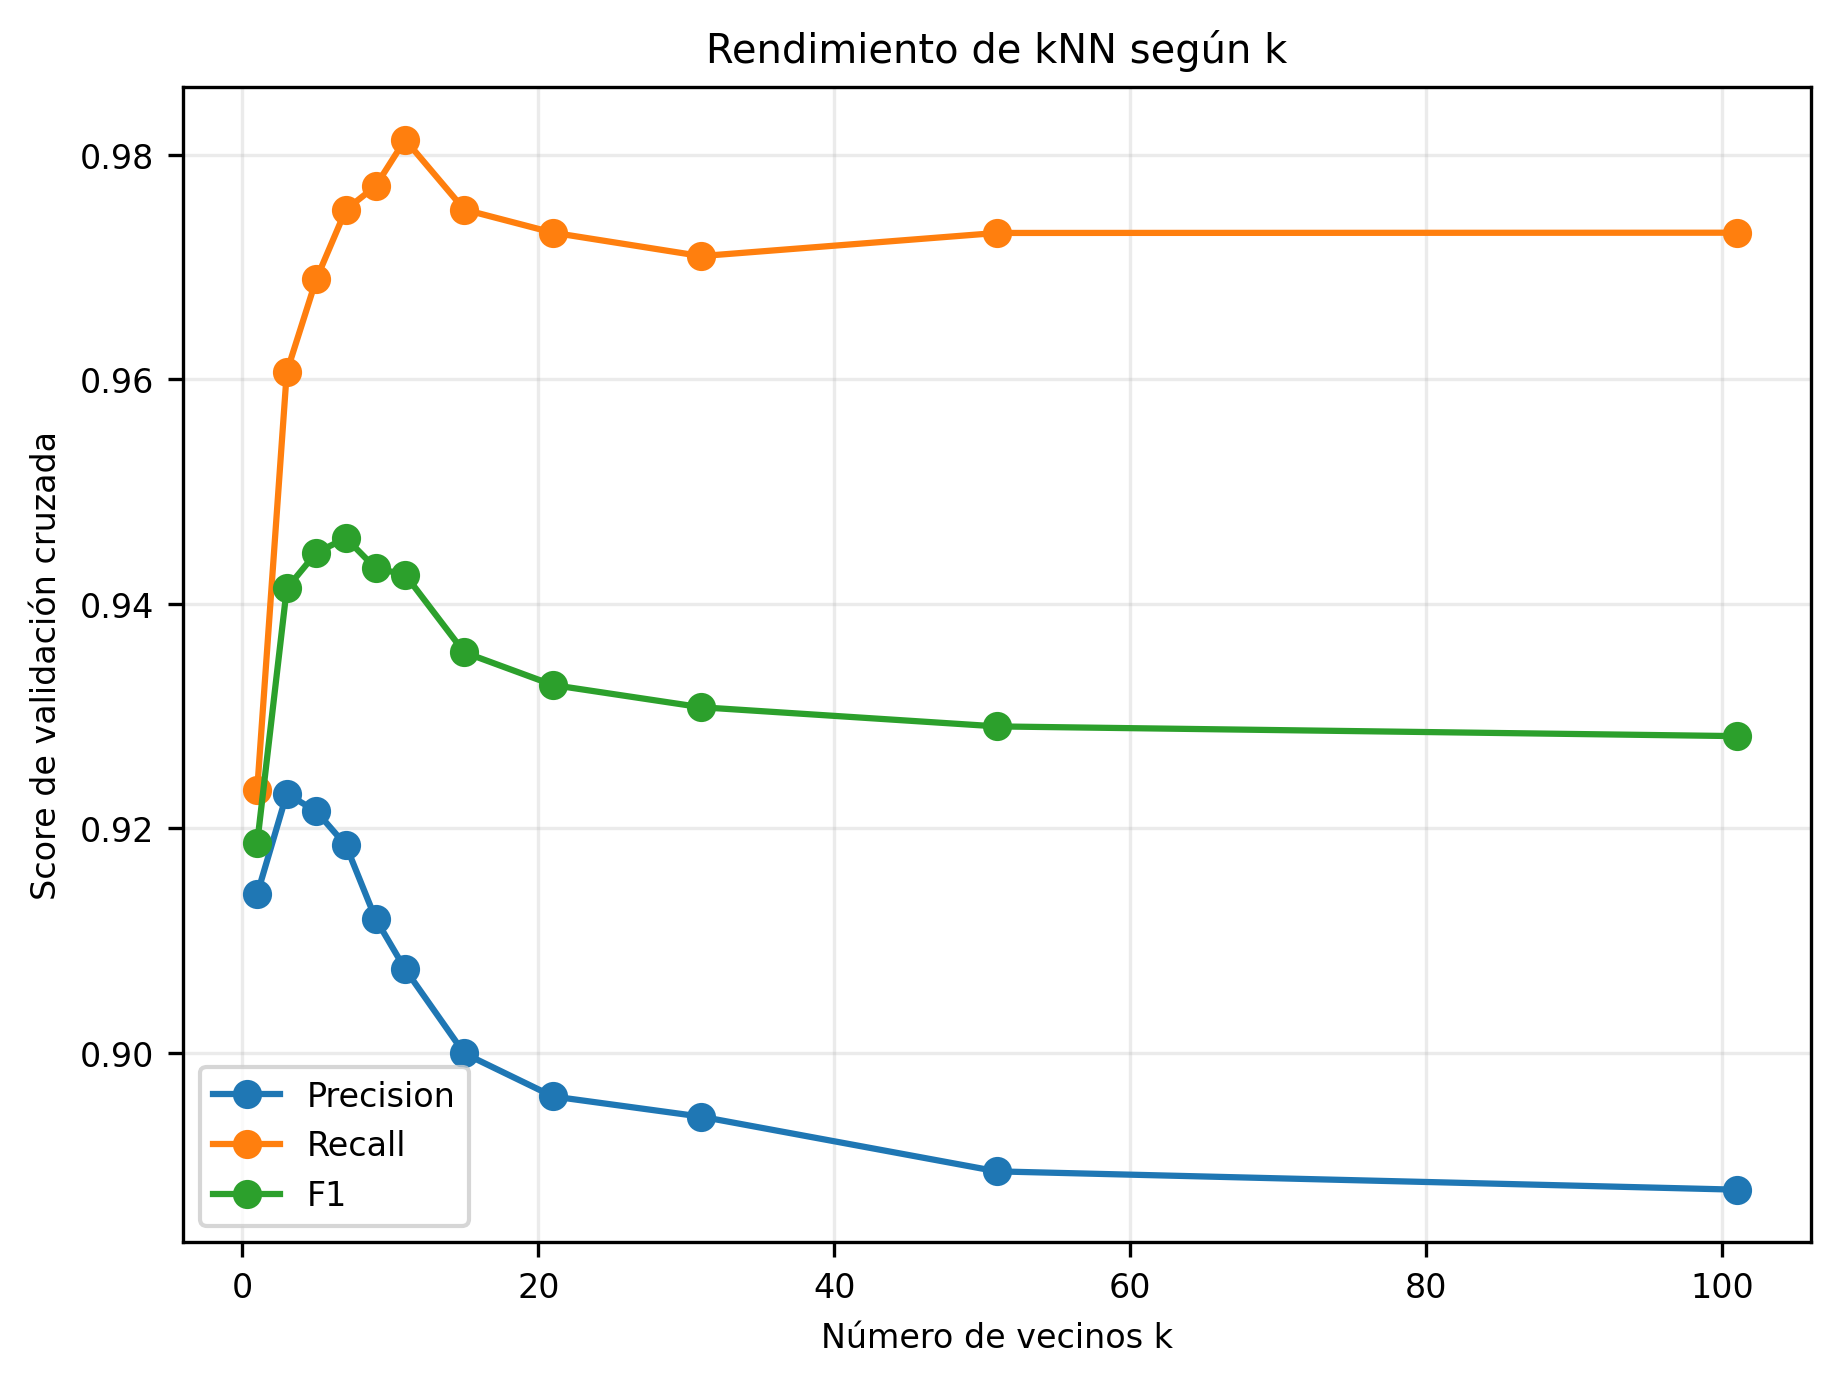

In [299]:
plt.figure(figsize=(7, 5))

for metrica in ["precision", "recall", "f1"]:
    plt.plot(
        resultados_k["k"],
        resultados_k[metrica],
        marker="o",
        label=metrica.capitalize()
    )

plt.xlabel("Número de vecinos k")
plt.ylabel("Score de validación cruzada")
plt.title("Rendimiento de kNN según k")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


### Respuestas

1. kNN con `k=5` tiene un rendimiento muy parecido al árbol simple. En algunas métricas queda un poco mejor, especialmente en recall y F1-score.

2. Cuando `k` es muy pequeño, como `k=1`, el modelo depende mucho de puntos individuales y puede terminar ajustándose al ruido.

3. Cuando `k` es muy grande, usa demasiados vecinos para decidir y la clasificación se vuelve demasiado general. Esto puede hacer que se pierdan diferencias más locales entre las clases.

4. De los valores probados, `k=7` da el mejor resultado general, con un buen balance entre precision y recall y el mayor F1-score. `k=5` queda bastante cerca.

5. kNN puede seguir formas más complejas en los datos porque clasifica según los puntos que tiene cerca, en vez de separar el espacio con cortes como hace un árbol.

## Cierre

En esta actividad vimos que evaluar un clasificador no consiste solo en obtener un score alto, sino en interpretar qué está midiendo cada métrica y cómo se construyen los conjuntos de validación. En este problema, el uso de validación cruzada estratificada fue importante para obtener una evaluación más estable y representativa.

También observamos que un modelo más complejo no siempre generaliza mejor. Aunque el árbol base ajustaba perfectamente los datos de entrenamiento, un árbol más simple logró mejores resultados en validación cruzada, lo que sugiere que reducir la complejidad ayudó a disminuir el sobreajuste.